#SP-XGBoost: Exploratory Data Analysis (EDA)
**Project**
SP-XGBoost: SHAP-Pruned + Bayesian-Optimised XGBoost for Early Academic Risk Prediction

In [11]:
# ==========================================
# Import Libraries
# Notebook 1: Exploratory Data Analysis (EDA)
# ==========================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [12]:
#Create Output Folders --This ensures all figures and tables are saved automatically.
# Project directories

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR = OUTPUT_DIR / "tables"

REPORT_DIR = OUTPUT_DIR / "reports"

for folder in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")


Folders created successfully.


In [13]:
#Load Dataset --Raw data
DATA_FILE = "../data/raw/SPhealth_student_data.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset Loaded Successfully")

#Dataset Overview
print("="*60)
print("Dataset Shape")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()       #Dataset Information
#df.head()      #First Observations 

Dataset Loaded Successfully
Dataset Shape
Rows    : 569
Columns : 67
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SID                            569 non-null    object 
 1   CGPA                           569 non-null    float64
 2   GPA_S1                         569 non-null    float64
 3   GPA_S2                         569 non-null    float64
 4   GPA_LAST                       569 non-null    float64
 5   CA_AVG                         569 non-null    float64
 6   EXAM_AVG                       569 non-null    float64
 7   CLIN_AVG                       569 non-null    float64
 8   LAB_AVG                        569 non-null    float64
 9   ATT_RATE                       569 non-null    float64
 10  FAIL_COUNT                     569 non-null    int64  
 11  REPEAT_COUNT                   569 non-nu

In [14]:
#Variable Dictionary
variable_dictionary = pd.DataFrame({
    "Variable":df.columns,
    "Data Type":df.dtypes.values,

    "Missing":df.isnull().sum().values,

    "Unique":df.nunique().values
})
#sAVE it 
variable_dictionary.to_csv(
    TABLE_DIR/"Variable_Dictionary.csv",
    index=False
)
#Missing Values
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)
missing = missing[missing>0]

#Missing Percentage
missing_percent = (
    df.isnull().mean()*100
).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent>0]
#Save
missing_percent.to_csv(
    TABLE_DIR/"Missing_Value_Report.csv"
)


Duplicate Records : 0


RISK_LABEL
Not At-Risk    412
At-Risk        157
Name: count, dtype: int64

RISK_LABEL
Not At-Risk    72.41
At-Risk        27.59
Name: proportion, dtype: float64

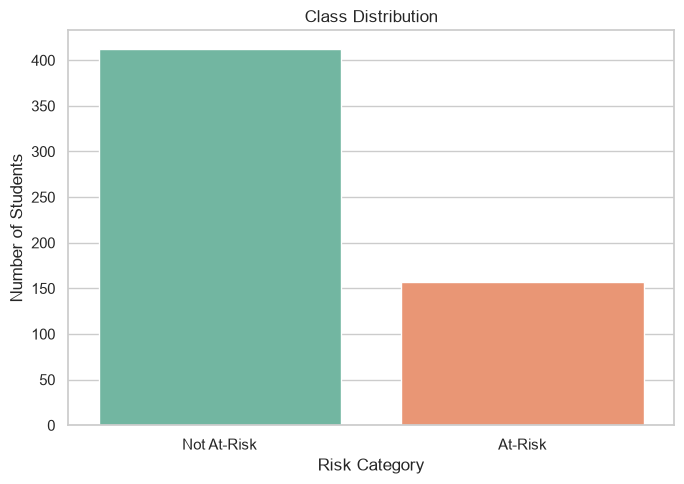

Number of Numerical Variables : 54
Number of Categorical Variables : 13


In [15]:
#Duplicate Records
duplicates = df.duplicated().sum()
print(f"Duplicate Records : {duplicates}")

#Class Distribution -- Target variable is:
TARGET = "RISK_LABEL"
class_counts = df[TARGET].value_counts()
class_percent = (
    df[TARGET]
    .value_counts(normalize=True)
    *100
).round(2)
display(class_counts)
display(class_percent)

#Plot Class Distribution
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x=TARGET,
    palette="Set2"
)
plt.title("Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Class_Distribution.png",
    dpi=300
)
plt.show()

#Datatype_summary
datatype_summary = (
    df.dtypes
    .value_counts()
    .rename_axis("Type")
    .reset_index(name="Count")
)
#Numerical Variables
numerical = df.select_dtypes(include=np.number)
print(f"Number of Numerical Variables : {numerical.shape[1]}")
numerical.columns.tolist()

#Categorical Variables
categorical = df.select_dtypes(
    exclude=np.number
)
print(f"Number of Categorical Variables : {categorical.shape[1]}")
categorical.columns.tolist()

#Summary Statistics
summary = numerical.describe().T
summary.to_csv(            #Save
    TABLE_DIR/"Numerical_Summary.csv"
)    

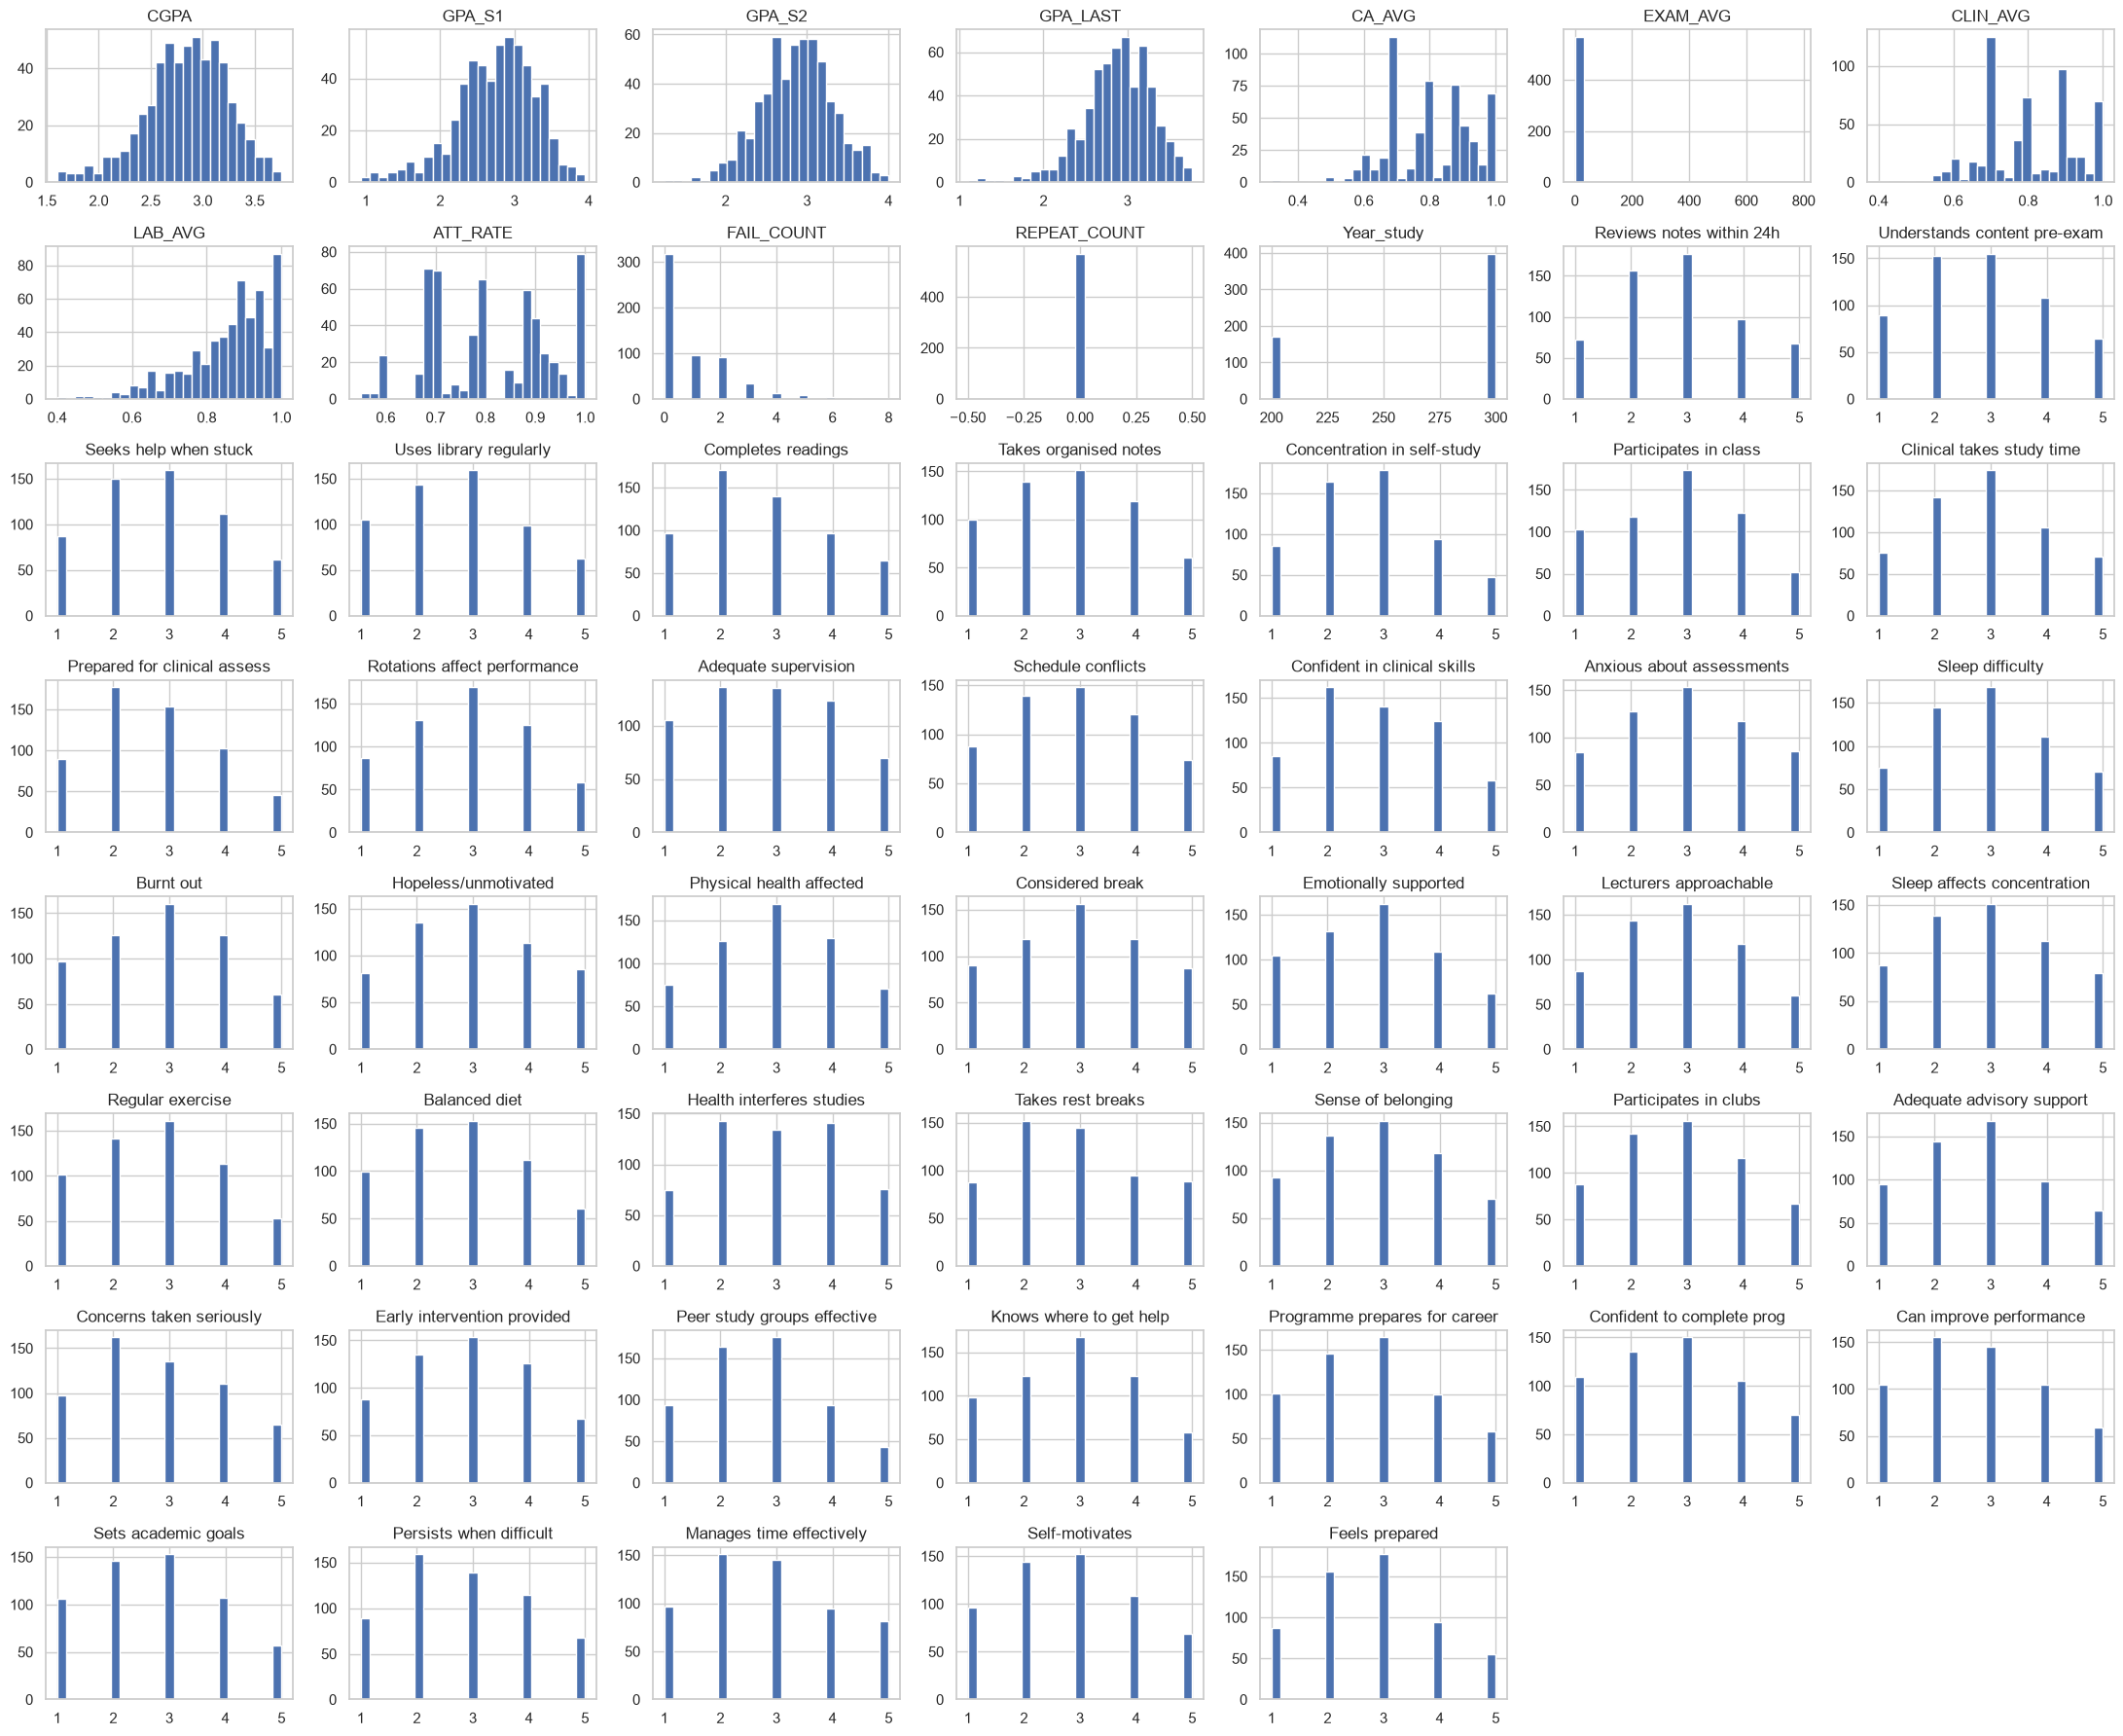

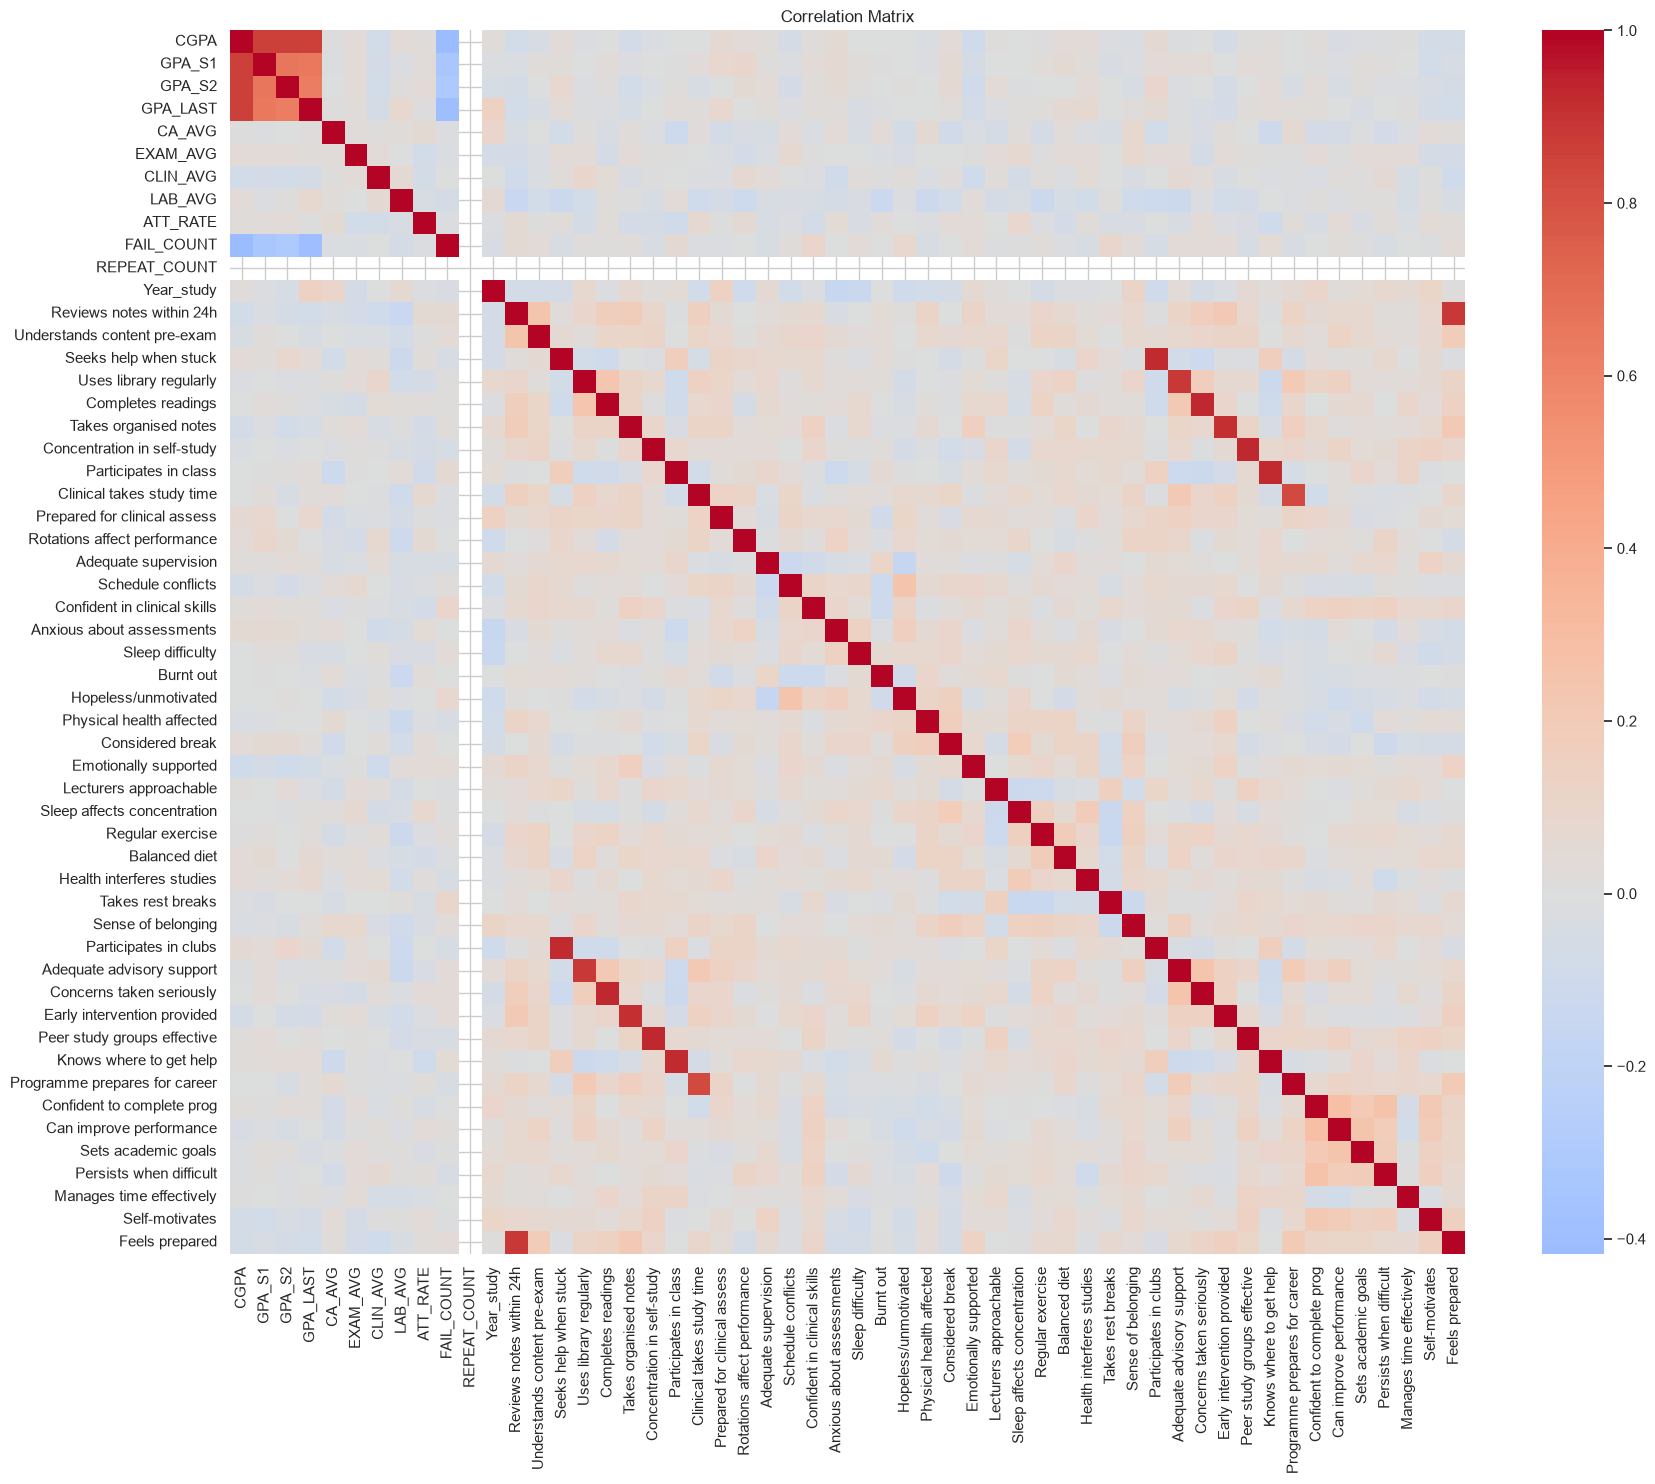


SP-XGBoost Exploratory Data Analysis Report
Dataset Size
Rows : 569
Columns : 67
Duplicate Records: 0
Missing Variables: 0
Target Distribution
RISK_LABEL
Not At-Risk    412
At-Risk        157



In [16]:
#Histograms
numerical.hist(
    figsize=(22,18),
    bins=25
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Histograms.png",
    dpi=300
)
plt.show()

#Correlation Matrix
corr = numerical.corr()
plt.figure(figsize=(18,15))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Correlation_Matrix.png",
    dpi=300
)
plt.show()

#Initial EDA Report
report = f"""
SP-XGBoost Exploratory Data Analysis Report
======================================
Dataset Size
Rows : {df.shape[0]}
Columns : {df.shape[1]}
Duplicate Records: {duplicates}
Missing Variables: {missing.shape[0]}
Target Distribution
{class_counts.to_string()}
"""
print(report)
#Save
with open(
    REPORT_DIR/"EDA_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

In [17]:
# ===========================================
# Outlier Detection (IQR Method)
# ===========================================
outlier_summary = []
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Variable": col,
        "Outliers": outliers,
        "Percentage": round(outliers / len(df) * 100, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(
    "Outliers",
    ascending=False
)# save
outlier_df.to_csv(
    TABLE_DIR/"Outlier_Report.csv",
    index=False
)

#Boxplots for All Numerical Variables
plt.figure(figsize=(8,2))
sns.boxplot(
        x=df[col]
    )
plt.title(col)
plt.tight_layout()
plt.savefig(
        FIGURE_DIR/f"{col}_boxplot.png",
        dpi=300
    )
plt.close()
    
#Categorical Variable Summary
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    print("="*60)
    print(col)
    print("="*60)
    display(df[col].value_counts())
    print()
#Chi-Square Test   --This examine's the relationship between categorical variables and RISK_LABEL.
from scipy.stats import chi2_contingency
chi_results = []
for col in categorical_cols:
    if col != TARGET:
        table = pd.crosstab(
            df[col],
            df[TARGET]
        )
        chi2, p, dof, exp = chi2_contingency(table)
        chi_results.append({
            "Variable": col,
            "Chi-square": round(chi2,3),
            "p-value": round(p,5)
        })
chi_df = pd.DataFrame(chi_results)
chi_df = chi_df.sort_values("p-value")
#chi_df--save
chi_df.to_csv(
    TABLE_DIR/"ChiSquare_Test.csv",
    index=False
)

SID


SID
HS2026001    1
HS2026002    1
HS2026003    1
HS2026004    1
HS2026005    1
            ..
HS2026565    1
HS2026566    1
HS2026567    1
HS2026568    1
HS2026569    1
Name: count, Length: 569, dtype: int64


WARN_STATUS


WARN_STATUS
No     552
Yes     17
Name: count, dtype: int64


ASSIGN_LATE


...

Sleep_hrs
4-5 hours            190
6-7 hours            155
5-6 hours            100
More than 8 hours     86
Less than 4 hours     33
7-8 hours              5
Name: count, dtype: int64


Self_risk_percep


Self_risk_percep
Moderate risk    209
Low risk         208
High risk         86
Very low risk     66
Name: count, dtype: int64


RISK_LABEL


RISK_LABEL
Not At-Risk    412
At-Risk        157
Name: count, dtype: int64

In [18]:
#Variables with (p < 0.05) are statistically associated with academic risk.
#compare numerical variables between (At-Risk vs Not At-Risk)
#First identify the two classes.
df[TARGET].value_counts()
#Suppose they are At-Risk and Not At-Risk, Then
from scipy.stats import mannwhitneyu
results = []
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    group1 = df[df[TARGET]=="At-Risk"][col]
    group2 = df[df[TARGET]=="Not At-Risk"][col]
    stat, p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )
    results.append({
        "Variable":col,
        "p-value":round(p,5)
    })
mw_df = pd.DataFrame(results)
mw_df = mw_df.sort_values("p-value")
#Save
mw_df.to_csv(
    TABLE_DIR/"MannWhitney_Test.csv",
    index=False
)

#Correlation with Target
#Since the target will eventually become binary(0 and 1)
#temporary encoded target.
df["Risk_Binary"] = (
    df[TARGET]
    .map({
        "Not At-Risk":0,
        "At-Risk":1
    })
)#Now-corr_target
corr_target = (
    df.corr(numeric_only=True)
    ["Risk_Binary"]
    .sort_values(
        ascending=False
    )
) #save
corr_target.to_csv(
    TABLE_DIR/"Target_Correlation.csv"
)

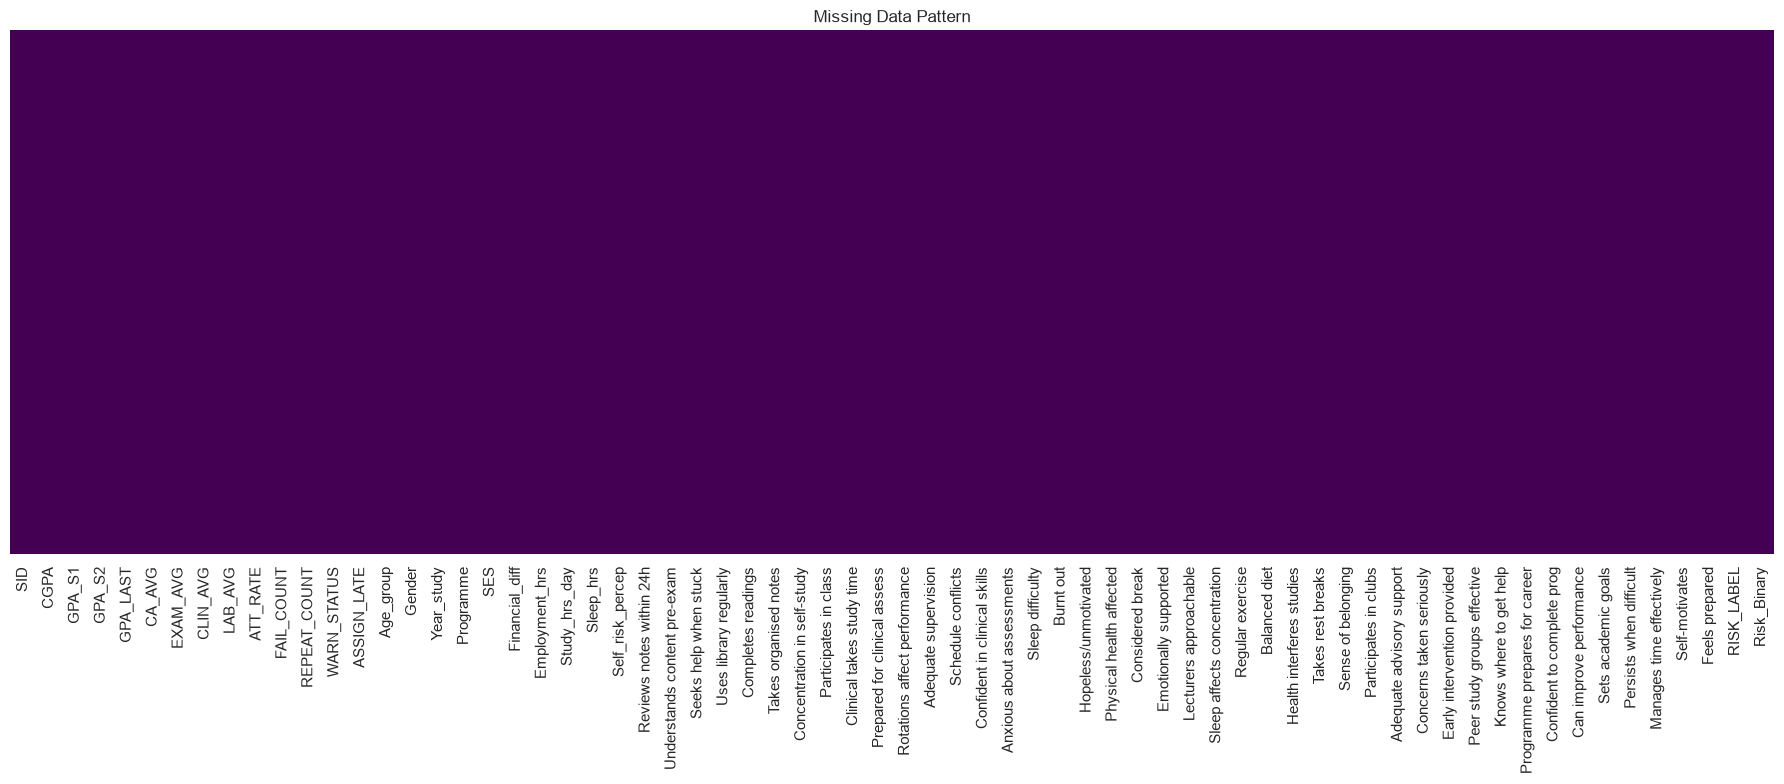

EDA COMPLETED
Students                : 569
Variables               : 68
Duplicate Records       : 0
Variables with Missing  : 0
Numerical Variables     : 54
Categorical Variables   : 13


In [19]:
#Missing Data Heatmap
plt.figure(figsize=(18,8))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)
plt.title("Missing Data Pattern")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Missing_Heatmap.png",
    dpi=300
)
plt.show()

#Feature Completeness --feature_quality
feature_quality = pd.DataFrame({
    "Variable":df.columns,
    "Missing %":(
        df.isnull().mean()*100
    ).round(2),
    "Unique":df.nunique()
})
#save
feature_quality.to_csv(
    TABLE_DIR/"Feature_Quality.csv",
    index=False
)

#Final EDA Summary --Final EDA Summary --Final EDA Summary
print("="*60)
print("EDA COMPLETED")
print("="*60)
print(f"Students                : {df.shape[0]}")
print(f"Variables               : {df.shape[1]}")
print(f"Duplicate Records       : {duplicates}")
print(f"Variables with Missing  : {len(missing)}")
print(f"Numerical Variables     : {len(numeric_cols)}")
print(f"Categorical Variables   : {len(categorical_cols)}")